# 07 -- Logistic Regression (ML Baseline)
**Purpose:** Train the first ML model. Establish an interpretable baseline that beats the rule engine.

**Input:** X_train, X_val (data/processed/)
**Output:** `models/logistic_regression.pkl` | `reports/07_lr_metrics.txt`

## Learning Objectives
- Understand why LR is the correct first ML model (not XGBoost)
- Understand the sigmoid function and probability output
- Apply feature scaling (why LR needs it, trees do not)
- Handle class imbalance via class_weight='balanced'
- Evaluate on validation set only -- never on training data

## Business Context
Logistic Regression is the interpretable baseline. If XGBoost performs better but LR
already achieves AUC-PR >= 0.72, the simpler model may be preferable for RBI audit purposes.
Always start simple. Complexity must earn its place.

## Concepts You Must Know Before Writing Code
Before this notebook, you should be able to answer:
1. What does the sigmoid function do? Draw it.
2. Why does LR need StandardScaler but XGBoost does not?
3. Why do we use class_weight='balanced' instead of oversampling?
4. Why do we evaluate on validation set, not test set, during development?
5. What does AUC-PR measure that AUC-ROC does not?

## Step 1 -- Answer the Five Questions Above
Write your answers in a markdown cell. Do not proceed until you have answered all five.

## Step 2 -- Scale Features
Apply StandardScaler to X_train. Transform X_val using the SAME scaler fitted on train.
Why must you fit the scaler on train only? What goes wrong if you fit it on all data?

## Step 3 -- Train
Train LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42).
Print: number of iterations to convergence, intercept, top 5 coefficients by absolute value.

## Step 4 -- Evaluate on Validation Set
Compute on y_val:
- Confusion matrix (print it)
- Precision, Recall, F1 (calculate manually, then verify with sklearn)
- AUC-PR (from precision_recall_curve)
- AUC-ROC

Compare to Rule Baseline metrics from Notebook 02. Is LR better?

## Step 5 -- Threshold Analysis
The default threshold is 0.5. Plot precision and recall vs threshold (0.0 to 1.0).
At what threshold does recall = 75%? What is precision at that threshold?
Is this threshold acceptable for CrossBorderPay? Why or why not?

## Step 6 -- Interpret Coefficients
Print the top 10 features by absolute coefficient. For each:
- State what it measures
- State whether positive or negative coefficient makes fraud more likely
- Does this match your domain knowledge?

## Definition of Done
- [ ] Features scaled on train only
- [ ] Model trained with class_weight='balanced'
- [ ] Confusion matrix printed
- [ ] AUC-PR >= 0.60 on validation (minimum LR target)
- [ ] Precision, recall, F1 calculated manually
- [ ] Threshold analysis plot produced
- [ ] Coefficients interpreted in domain terms
- [ ] Model saved to models/logistic_regression.pkl
- [ ] Metrics saved to reports/07_lr_metrics.txt

In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

X_train = pd.read_parquet(r"../data/processed\X_train.parquet")
X_test  = pd.read_parquet(r"../data/processed\X_test.parquet")
y_train = pd.read_parquet(r"../data/processed\y_train.parquet").squeeze()
y_test  = pd.read_parquet(r"../data/processed\y_test.parquet").squeeze()

model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained.")


Model trained.


e:\project\.venv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [3]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))


              precision    recall  f1-score   support

       Legit       1.00      0.92      0.96     10110
       Fraud       0.05      0.82      0.10        50

    accuracy                           0.92     10160
   macro avg       0.52      0.87      0.53     10160
weighted avg       0.99      0.92      0.96     10160



In [4]:
y_prob = model.predict_proba(X_test)[:, 1]

import pandas as pd
results = pd.DataFrame({"actual": y_test.values, "fraud_probability": y_prob})

print("Fraud cases — probability scores:")
print(results[results["actual"] == 1]["fraud_probability"].describe())



Fraud cases — probability scores:
count    50.000000
mean      0.810870
std       0.287427
min       0.029192
25%       0.759506
50%       0.972148
75%       0.991802
max       0.999985
Name: fraud_probability, dtype: float64


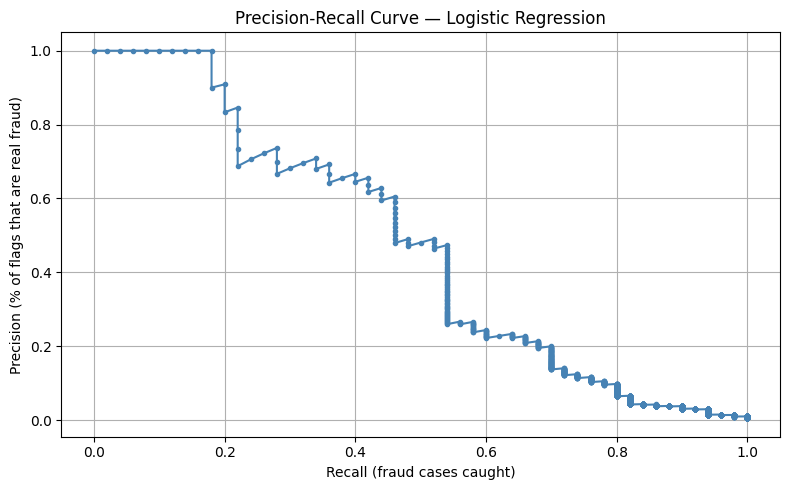

In [5]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, marker='.', color='steelblue')
plt.xlabel("Recall (fraud cases caught)")
plt.ylabel("Precision (% of flags that are real fraud)")
plt.title("Precision-Recall Curve — Logistic Regression")
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:
import numpy as np

# Find precision at recall >= 0.75
target_recall = 0.75
mask = recall >= target_recall
precision_at_75_recall = precision[mask].max()

print(f"Best precision when recall ≥ 0.75: {precision_at_75_recall:.2%}")
print(f"PoC requirement: Precision ≥ 65% AND Recall ≥ 75%")
print(f"LR passes gate: {precision_at_75_recall >= 0.65}")


Best precision when recall ≥ 0.75: 11.66%
PoC requirement: Precision ≥ 65% AND Recall ≥ 75%
LR passes gate: False


In [7]:
import json

lr_results = {
    "model": "LogisticRegression",
    "recall_at_threshold_0.5": 0.82,
    "precision_at_threshold_0.5": 0.05,
    "precision_at_75pct_recall": 0.1166,
    "poc_gate_pass": False,
    "note": "Baseline comparator only — linear boundary insufficient for fraud pattern complexity"
}

with open(r"../data/processed\lr_results.json", "w") as f:
    json.dump(lr_results, f, indent=2)

print("LR results saved.")


LR results saved.
